In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [4]:
data = {
    "Review": [
        "I love this product",
        "This is amazing",
        "Excellent quality",
        "Very happy with purchase",
        "Highly recommended",
        "Worst product ever",
        "Very bad experience",
        "Waste of money",
        "Poor quality",
        "Not satisfied",
        "Fantastic service",
        "I enjoyed using this",
        "Terrible item",
        "Very disappointing",
        "Superb performance",
        "Excellent support",
        "Bad packaging",
        "Horrible experience",
        "Really good",
        "Not worth buying"
    ],

    "Sentiment": [
        "Positive",
        "Positive",
        "Positive",
        "Positive",
        "Positive",
        "Negative",
        "Negative",
        "Negative",
        "Negative",
        "Negative",
        "Positive",
        "Positive",
        "Negative",
        "Negative",
        "Positive",
        "Positive",
        "Negative",
        "Negative",
        "Positive",
        "Negative"
    ]
}

df = pd.DataFrame(data)

print("Dataset:")
print(df.head())

Dataset:
                     Review Sentiment
0       I love this product  Positive
1           This is amazing  Positive
2         Excellent quality  Positive
3  Very happy with purchase  Positive
4        Highly recommended  Positive


In [5]:
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df["Review"],
    df["Sentiment"],
    test_size=0.30,
    random_state=42,
    stratify=df["Sentiment"])

In [7]:
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english")),
    ("rf", RandomForestClassifier(n_estimators=100,
    random_state=42))])

In [8]:
pipeline.fit(X_train_text, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('tfidf', ...), ('rf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['Negative','Positive']"
,"stop_words stop_words: {'english'}, list, default=NoneIf a string, it is passed to _check_stop_list and the appropriate stoplist is returned. 'english' is currently the only supported stringvalue.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",'english'
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is

In [9]:
cv_scores = cross_val_score(
    pipeline,
    X_train_text,
    y_train,
    cv=5)

print("\nCross-Validation Scores:")
print(cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())


Cross-Validation Scores:
[0.66666667 0.66666667 0.33333333 0.66666667 0.5       ]
Mean CV Accuracy: 0.5666666666666667


In [10]:
y_pred = pipeline.predict(X_test_text)

In [11]:
print("\nPredictions\n")

for actual, predicted in zip(y_test, y_pred):

    print("Actual    :", actual)
    print("Predicted :", predicted)

    if actual == predicted:
        print("Correct Prediction\n")
    else:
        print("Wrong Prediction\n")



Predictions

Actual    : Negative
Predicted : Positive
Wrong Prediction

Actual    : Positive
Predicted : Positive
Correct Prediction

Actual    : Negative
Predicted : Positive
Wrong Prediction

Actual    : Positive
Predicted : Positive
Correct Prediction

Actual    : Positive
Predicted : Positive
Correct Prediction

Actual    : Negative
Predicted : Positive
Wrong Prediction



In [12]:
accuracy = accuracy_score(y_test, y_pred)

print("Test Accuracy:", accuracy)


Test Accuracy: 0.5


In [13]:
print("\nClassification Report\n")

print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0))


Classification Report

              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00         3
    Positive       0.50      1.00      0.67         3

    accuracy                           0.50         6
   macro avg       0.25      0.50      0.33         6
weighted avg       0.25      0.50      0.33         6



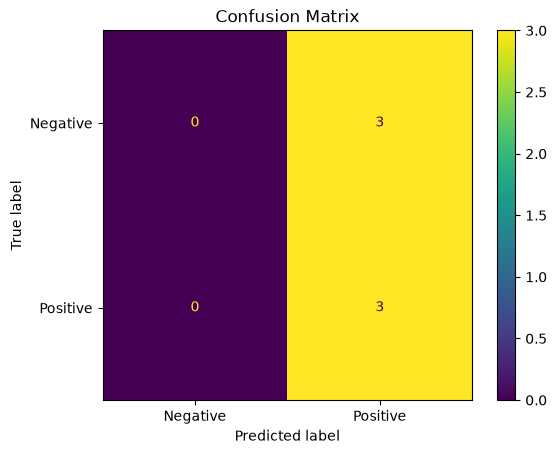

In [14]:
ConfusionMatrixDisplay.from_estimator(
    pipeline,
    X_test_text,
    y_test
)

plt.title("Confusion Matrix")
plt.show()


In [15]:
new_review = ["This product is excellent"]

prediction = pipeline.predict(new_review)

print("\nNew Review :", new_review[0])
print("Predicted Sentiment :", prediction[0])


New Review : This product is excellent
Predicted Sentiment : Positive
